# 03 — Stress testing results and controls

This notebook makes the stress transmission and management interpretation inspectable. Baseline must reconcile exactly to portfolio expected loss.

In [1]:
from pathlib import Path
import os
import sys
import yaml
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from src.data_ingestion import fetch_macro_data, generate_panel
from src.eda_portfolio import latest_snapshot
from src.stress_testing import run as run_stress

with open('config.yaml', encoding='utf-8') as handle:
    config = yaml.safe_load(handle)
macro = fetch_macro_data(config)
panel = generate_panel(1200, seed=config['project']['seed'], macro_df=macro)
current = latest_snapshot(panel)
stress = run_stress(current, config)

## Scenario outcomes

In [2]:
summary = stress['summary'][[
    'scenario', 'el_base_pct_ead', 'el_stressed_pct_ead', 'el_delta_pct_ead'
]].copy()
summary

,scenario,el_base_pct_ead,el_stressed_pct_ead,el_delta_pct_ead
0,baseline,2.170616,2.170616,0.000000
1,mild_recession,2.170616,3.149372,0.978756
2,severe_recession,2.170616,5.526808,3.356192
3,stagflation,2.170616,3.862533,1.691917


In [3]:
baseline_detail = stress['scenario_details']['baseline']
reconciliation_error = (
    baseline_detail.el_stressed.sum() - baseline_detail.expected_loss.sum()
)
assert abs(reconciliation_error) < 1e-6
f'Baseline reconciliation error: £{reconciliation_error:,.2f}'

'Baseline reconciliation error: £0.00'

## Severe-scenario sector contribution

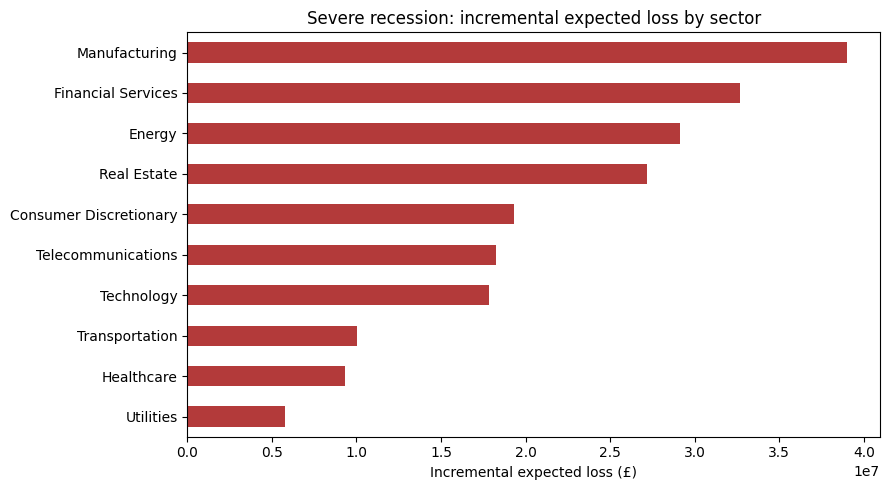

In [4]:
sector = stress['sector_sensitivity'].sort_values('el_delta')
sector.plot.barh(
    x='sector', y='el_delta', legend=False, figsize=(9, 5), color='#B33A3A',
    title='Severe recession: incremental expected loss by sector'
)
plt.xlabel('Incremental expected loss (£)'); plt.ylabel(''); plt.tight_layout();

## Risk appetite decision

In [5]:
limit = config['credit_risk']['risk_appetite']['severe_el_uplift_limit_ppts']
severe = summary.query("scenario == 'severe_recession'").iloc[0]
pd.Series({
    'severe_el_uplift_ppts': severe.el_delta_pct_ead,
    'illustrative_limit_ppts': limit,
    'status': 'BREACH' if severe.el_delta_pct_ead > limit else 'WITHIN LIMIT',
    'largest_contributor': stress['sector_sensitivity'].iloc[0].sector,
}).to_frame('result')

,result
severe_el_uplift_ppts,3.356192
illustrative_limit_ppts,2.5
status,BREACH
largest_contributor,Manufacturing


## Interpretation and limitation

The breach is a trigger for sector/name review, not an automatic credit action. The engine stresses PD, collateral/LGD and revolver utilisation/EAD; it does not model scenario probability, default correlation, contagion, FX or management response, so results are sensitivities rather than capital or IFRS 9 forecasts.